In [32]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

## Keypoints

In [33]:
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils 


In [34]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, results
    

In [35]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS)
    mp_drawing,draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
    

In [36]:
def draw_styled_landmarks(image, results):
    # pose connections - green
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                              mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=1, circle_radius=1),
                              mp_drawing.DrawingSpec(color=(0,128,0), thickness=1, circle_radius=1)
                              )
    # left hand connections - red
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                              mp_drawing.DrawingSpec(color=(255, 0, 0), thickness=1, circle_radius=1),
                              mp_drawing.DrawingSpec(color=(128, 0, 0), thickness=1, circle_radius=1)
                              )
    # right hand connections - blue
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                              mp_drawing.DrawingSpec(color=(0,0,255), thickness=1, circle_radius=1),
                              mp_drawing.DrawingSpec(color=(0,0,128), thickness=1, circle_radius=1)
                              )
    

In [37]:
def capture():
    cap = cv2.VideoCapture(0)
    # mp_holistic = mp_holistic.Holistic(static_image_mode=False, model_complexity=1, enable_segmentation=False, refine_face_landmarks=False)

    with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5, refine_face_landmarks=False) as holistic:
        while cap.isOpened():
            
            ret, frame = cap.read()
            
            image, results = mediapipe_detection(frame, holistic)
            print(results)
            
            draw_styled_landmarks(image, results)
            
            cv2.imshow('opencv feed', image)
            
            if cv2.waitKey(10) & 0xFF == ord('q'):
                break
            
        cap.release()
        cv2.destroyAllWindows()
        
    return ret, frame, image, results
        

In [38]:
ret, frame, image, results = capture()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

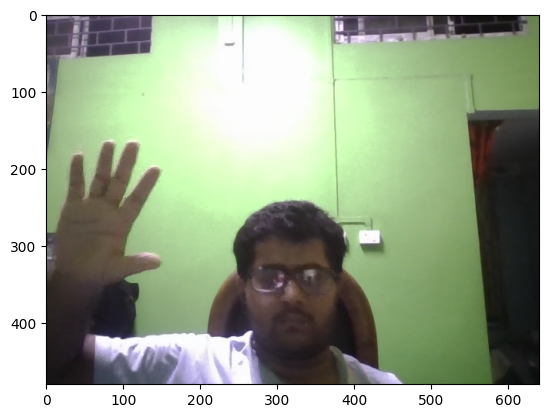

In [39]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

## Extract Keypoint

In [30]:
len(results.left_hand_landmarks)

TypeError: object of type 'NoneType' has no len()